In [ ]:
# import some packages

import matplotlib.pyplot as plt
import numpy as np
import torch

from experiment.train import train_model
from experiment.transformer import TransformerModel, setup_transformer_config
from experiment.util import make_series
from si4attention.abstract import Transformer

torch.cuda.is_available()

In [ ]:
# set up the configuration and make the model
series_size = 256
architecture_size = "small"

model = TransformerModel(
    setup_transformer_config("series", series_size, architecture_size),
)

In [4]:
# make training dataset

rng = np.random.default_rng(0)

x_positive = make_series(rng, series_size, cov=1.0, signal=(1.0, 4.0), num=1000)
x_negative = make_series(rng, series_size, cov=1.0, signal=0.0, num=1000)
x = np.concatenate([x_positive, x_negative])
x = torch.tensor(x).float()
y = np.concatenate([np.ones((1000, 1)), np.zeros((1000, 1))])
y = torch.tensor(y).float()

In [ ]:
# training the model

model = train_model(model, x, y)

th = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.sum((model(x.to(device)) > th) == y.bool().to(device)) / 2000)

In [135]:
model.to("cpu")
torch.save(model.state_dict(), f"model/series_{series_size}_{architecture_size}.pth")

14.981194109457018


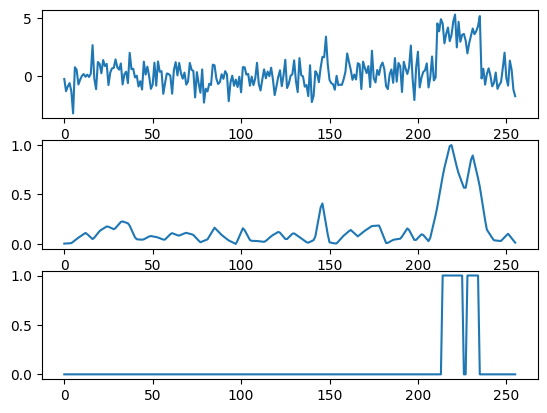

In [10]:
input = make_series(rng, series_size, cov=1.0, signal=4.0)
input_ = torch.from_numpy(input).float()
tau = 0.6

map_ = Transformer(model, "series").attention_map(input_).detach().numpy()

fig, ax = plt.subplots(3, 1)
ax[0].plot(input[0, 0, :])
ax[1].plot(map_[0, :])
ax[2].plot(map_[0, :] > tau)

mask = map_[0, :] > tau
eta = mask / np.sum(mask) - ((1.0 - mask) / np.sum(1.0 - mask))
stat = np.sum(eta * input[0, 0, :]) / np.linalg.norm(eta)
print(stat)

plt.show()